# Insurance Claims Fraud Detection & Anomaly Classification
**Dataset:** Auto Insurance Claims Fraud Detection (`insurance_claims.csv`).
**Dimensi Data:** 1.000 klaim asuransi kendaraan bermotor dengan 39 variabel risiko penjelas dan target biner `fraud_reported`.

Notebook ini membangun pipeline deteksi anomali dan klaim penipuan (*fraud detection*) terstandarisasi untuk unit investigasi khusus (*Special Investigation Unit / SIU*). Evaluasi metrik berfokus pada PR-AUC (Precision-Recall AUC), ROC-AUC, dan Cost-Sensitive Recall untuk meminimalisir lolosnya klaim fiktif (*False Negatives*).

### Arsitektur Pipeline Analisis:
1. **Data Ingestion & Cleaning**: Pembersihan artefak kolom tak terpakai (`_c39`, identifier `policy_number`), konversi nilai `?` menjadi missing values.
2. **Fraud Risk Profiling (EDA)**: Analisis hubungan keparahan insiden (`incident_severity`), rasio klaim kendaraan terhadap premi, dan jam terjadinya insiden terhadap status fraud.
3. **Zero-Leakage Preprocessing**: Train-Test split terisolasi (80:20), imputasi modus/median fit khusus `X_train`, target/one-hot encoding, dan penanganan ketidakseimbangan kelas (*Class Weights* & *SMOTE*).
4. **Supervised Model Comparison**: Logistic Regression (Baseline Terbobot), Random Forest Classifier, dan Gradient Boosting (LightGBM & XGBoost).
5. **Cost-Sensitive Evaluation**: Analisis kurva Precision-Recall (PR-AUC), ROC-AUC, Confusion Matrix, dan identifikasi *Feature Importance* risiko fraud teratas.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, classification_report, confusion_matrix, f1_score
)
import lightgbm as lgb

os.makedirs('images', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
    'figure.figsize': (12, 6)
})

print("Konfigurasi pustaka dan visualisasi fraud detection berhasil diinisialisasi.")

Konfigurasi pustaka dan visualisasi fraud detection berhasil diinisialisasi.


In [2]:
df = pd.read_csv('data/insurance_claims.csv')

# Hapus kolom artefak kosong jika ada
if '_c39' in df.columns:
    df = df.drop(columns=['_c39'])

# Ganti placeholder '?' dengan NaN
df = df.replace('?', np.nan)

# Konversi target biner (Y = 1, N = 0)
df['fraud_reported_num'] = (df['fraud_reported'] == 'Y').astype(int)

print(f"Dimensi data klaim: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print("\nDistribusi Target Fraud Reported:")
print(df['fraud_reported'].value_counts(normalize=True))
df.head()

Dimensi data klaim: 1,000 baris x 40 kolom

Distribusi Target Fraud Reported:
fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,fraud_reported_num
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,1
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,NaN,5070,780,780,3510,Mercedes,E400,2007,Y,1
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,0
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,1
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13632\188368442.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_sev, x='incident_severity', y='fraud_reported_num', palette='Reds_r', ax=axes[0, 0])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13632\188368442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount', palette='Set2', ax=axes[0, 1])


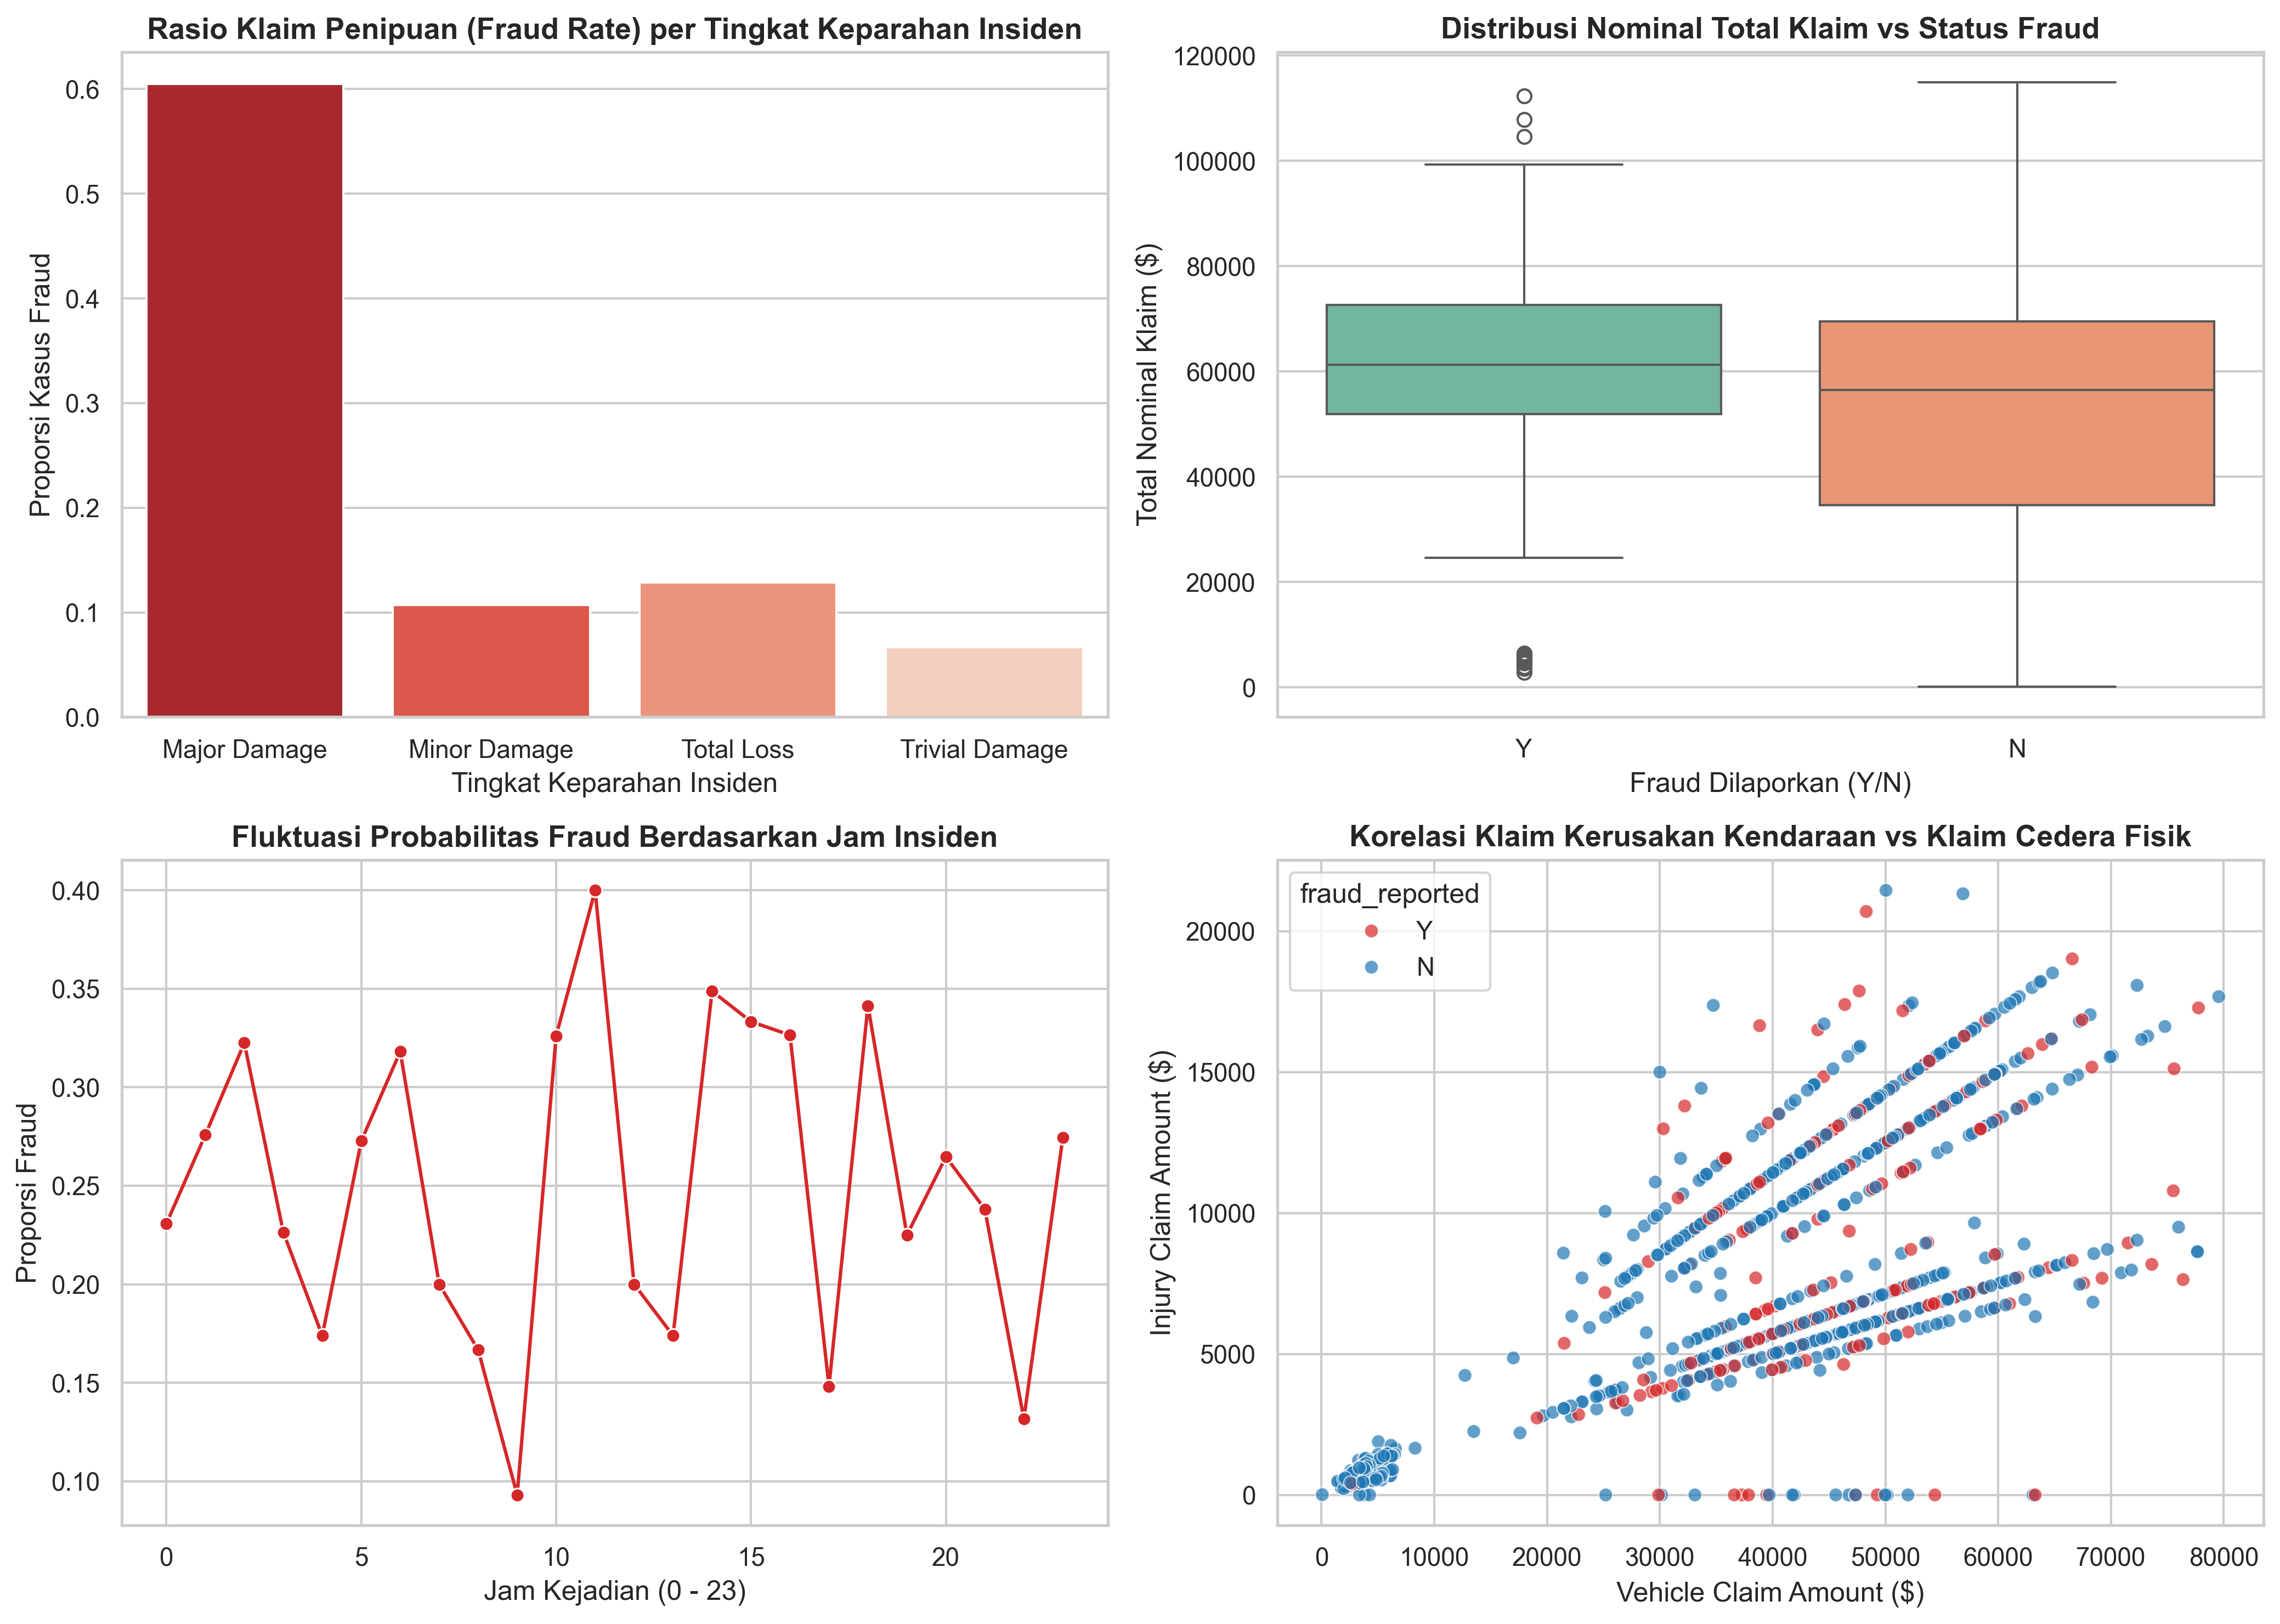

Visualisasi profil risiko fraud berhasil diekspor ke images/fraud_risk_eda.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tingkat Fraud per Tingkat Keparahan Insiden (Incident Severity)
fraud_by_sev = df.groupby('incident_severity')['fraud_reported_num'].mean().reset_index()
sns.barplot(data=fraud_by_sev, x='incident_severity', y='fraud_reported_num', palette='Reds_r', ax=axes[0, 0])
axes[0, 0].set_title('Rasio Klaim Penipuan (Fraud Rate) per Tingkat Keparahan Insiden', fontweight='bold')
axes[0, 0].set_xlabel('Tingkat Keparahan Insiden')
axes[0, 0].set_ylabel('Proporsi Kasus Fraud')

# 2. Sebaran Total Klaim (Total Claim Amount) vs Fraud Reported
sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Distribusi Nominal Total Klaim vs Status Fraud', fontweight='bold')
axes[0, 1].set_xlabel('Fraud Dilaporkan (Y/N)')
axes[0, 1].set_ylabel('Total Nominal Klaim ($)')

# 3. Jam Kejadian Insiden (Incident Hour of the Day) vs Fraud
fraud_by_hour = df.groupby('incident_hour_of_the_day')['fraud_reported_num'].mean().reset_index()
sns.lineplot(data=fraud_by_hour, x='incident_hour_of_the_day', y='fraud_reported_num', marker='o', color='#d62728', ax=axes[1, 0])
axes[1, 0].set_title('Fluktuasi Probabilitas Fraud Berdasarkan Jam Insiden', fontweight='bold')
axes[1, 0].set_xlabel('Jam Kejadian (0 - 23)')
axes[1, 0].set_ylabel('Proporsi Fraud')

# 4. Komposisi Klaim: Vehicle Claim vs Injury Claim
sns.scatterplot(data=df, x='vehicle_claim', y='injury_claim', hue='fraud_reported', alpha=0.7, palette={'N': '#1f77b4', 'Y': '#d62728'}, ax=axes[1, 1])
axes[1, 1].set_title('Korelasi Klaim Kerusakan Kendaraan vs Klaim Cedera Fisik', fontweight='bold')
axes[1, 1].set_xlabel('Vehicle Claim Amount ($)')
axes[1, 1].set_ylabel('Injury Claim Amount ($)')

plt.tight_layout()
plt.savefig('images/fraud_risk_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi profil risiko fraud berhasil diekspor ke images/fraud_risk_eda.png")

In [4]:
# Preprocessing Pipeline Terisolasi (Mencegah Kebocoran Data)
drop_cols = ['policy_number', 'policy_bind_date', 'incident_date', 'incident_location', 'insured_zip', 'fraud_reported', 'fraud_reported_num']
X = df.drop(columns=drop_cols).copy()
y = df['fraud_reported_num'].values

# Feature Engineering: Rasio Klaim terhadap Premi Tahunan
X['claim_to_premium_ratio'] = X['total_claim_amount'] / (X['policy_annual_premium'] + 1e-5)
X['vehicle_claim_ratio'] = X['vehicle_claim'] / (X['total_claim_amount'] + 1e-5)

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Train-Test Split Terisolasi (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline Transformer: Imputasi Modus/Median + One-Hot Encoding
for c in cat_cols:
    mode_val = X_train[c].mode()[0]
    X_train[c] = X_train[c].fillna(mode_val)
    X_test[c] = X_test[c].fillna(mode_val)

for c in num_cols:
    med_val = X_train[c].median()
    X_train[c] = X_train[c].fillna(med_val)
    X_test[c] = X_test[c].fillna(med_val)

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])

X_train_enc = np.hstack([X_train[num_cols].values, ohe.transform(X_train[cat_cols])])
X_test_enc = np.hstack([X_test[num_cols].values, ohe.transform(X_test[cat_cols])])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

print(f"Ukuran sampel pelatihan: {X_train_scaled.shape[0]} baris x {X_train_scaled.shape[1]} fitur")
print(f"Ukuran sampel pengujian: {X_test_scaled.shape[0]} baris x {X_test_scaled.shape[1]} fitur")

Ukuran sampel pelatihan: 800 baris x 142 fitur
Ukuran sampel pengujian: 200 baris x 142 fitur


In [5]:
# Model Training & Baseline Comparison (Handling Class Imbalance)

# 1. Baseline: Logistic Regression Terbobot (Cost-Sensitive)
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)
prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest Classifier
model_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=8)
model_rf.fit(X_train_scaled, y_train)
prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

# 3. LightGBM Classifier (Scale Pos Weight)
scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)
model_lgb = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=42,
    verbose=-1
)
model_lgb.fit(X_train_scaled, y_train)
prob_lgb = model_lgb.predict_proba(X_test_scaled)[:, 1]

print("Seluruh model klasifikasi fraud detection selesai dilatih.")

Seluruh model klasifikasi fraud detection selesai dilatih.


=== EVALUASI PERFORMA MODEL FRAUD DETECTION ===
Logistic Regression : ROC-AUC = 0.7898 | PR-AUC = 0.4957
Random Forest       : ROC-AUC = 0.8215 | PR-AUC = 0.4964
LightGBM Classifier : ROC-AUC = 0.7973 | PR-AUC = 0.5248


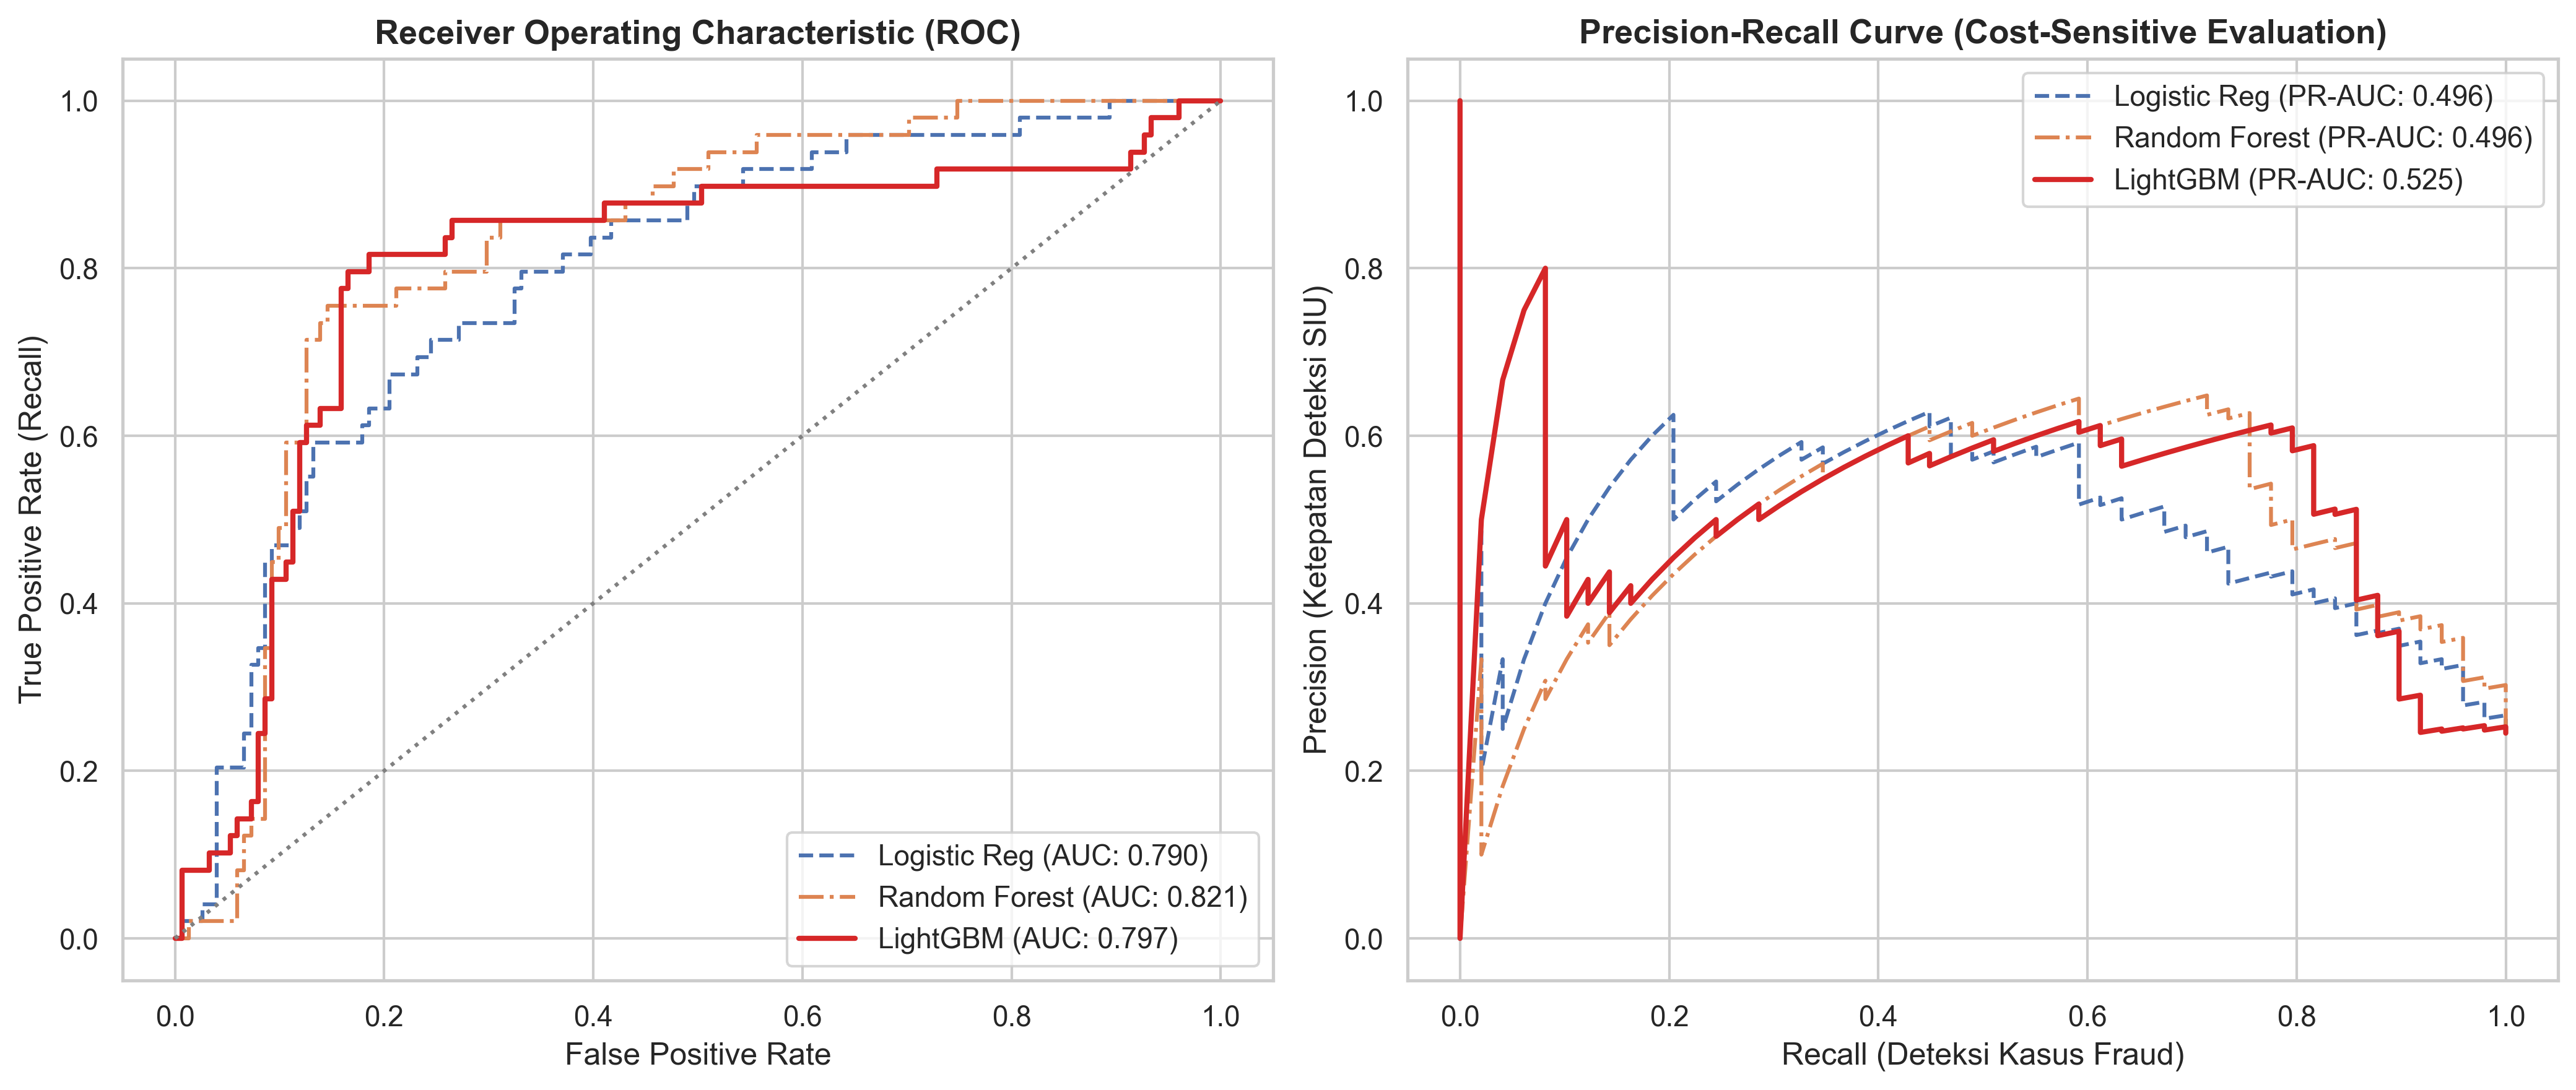

Visualisasi kurva evaluasi fraud berhasil diekspor ke images/fraud_detection_roc_pr_curve.png


In [6]:
# Evaluasi Kuantitatif: ROC-AUC, PR-AUC & Precision-Recall Curves
auc_lr = roc_auc_score(y_test, prob_lr)
auc_rf = roc_auc_score(y_test, prob_rf)
auc_lgb = roc_auc_score(y_test, prob_lgb)

prauc_lr = average_precision_score(y_test, prob_lr)
prauc_rf = average_precision_score(y_test, prob_rf)
prauc_lgb = average_precision_score(y_test, prob_lgb)

print("=== EVALUASI PERFORMA MODEL FRAUD DETECTION ===")
print(f"Logistic Regression : ROC-AUC = {auc_lr:.4f} | PR-AUC = {prauc_lr:.4f}")
print(f"Random Forest       : ROC-AUC = {auc_rf:.4f} | PR-AUC = {prauc_rf:.4f}")
print(f"LightGBM Classifier : ROC-AUC = {auc_lgb:.4f} | PR-AUC = {prauc_lgb:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, prob_lgb)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC: {auc_lr:.3f})', linestyle='--')
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC: {auc_rf:.3f})', linestyle='-.')
axes[0].plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC: {auc_lgb:.3f})', color='#d62728', lw=2)
axes[0].plot([0, 1], [0, 1], color='gray', linestyle=':')
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right')

# 2. Precision-Recall Curves (Krusial untuk Imbalanced Fraud Detection)
p_lr, r_lr, _ = precision_recall_curve(y_test, prob_lr)
p_rf, r_rf, _ = precision_recall_curve(y_test, prob_rf)
p_lgb, r_lgb, _ = precision_recall_curve(y_test, prob_lgb)

axes[1].plot(r_lr, p_lr, label=f'Logistic Reg (PR-AUC: {prauc_lr:.3f})', linestyle='--')
axes[1].plot(r_rf, p_rf, label=f'Random Forest (PR-AUC: {prauc_rf:.3f})', linestyle='-.')
axes[1].plot(r_lgb, p_lgb, label=f'LightGBM (PR-AUC: {prauc_lgb:.3f})', color='#d62728', lw=2)
axes[1].set_title('Precision-Recall Curve (Cost-Sensitive Evaluation)', fontweight='bold')
axes[1].set_xlabel('Recall (Deteksi Kasus Fraud)')
axes[1].set_ylabel('Precision (Ketepatan Deteksi SIU)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('images/fraud_detection_roc_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi kurva evaluasi fraud berhasil diekspor ke images/fraud_detection_roc_pr_curve.png")